# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

I chose a dataset from Zillow.com demonstrating monthly for-sale listings throught time. This spanned over several years. It provies a complete picture of the housing availability throught time, as well as in correlation during the pandemic.  

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load data
df = pd.read_csv("Zillow.csv")
print(df.head())
print(df.info())
                 


   RegionID  SizeRank       RegionName RegionType StateName  2018-03-31  \
0    102001         0    United States    country       NaN   1421529.0   
1    394913         1     New York, NY        msa        NY     73707.0   
2    753899         2  Los Angeles, CA        msa        CA     21998.0   
3    394463         3      Chicago, IL        msa        IL     38581.0   
4    394514         4       Dallas, TX        msa        TX     24042.0   

   2018-04-30  2018-05-31  2018-06-30  2018-07-31  ...  2025-07-31  \
0   1500195.0   1592417.0   1660618.0   1709146.0  ...   1373264.0   
1     80345.0     85864.0     90067.0     91881.0  ...     49038.0   
2     23784.0     25605.0     27109.0     28811.0  ...     26379.0   
3     42253.0     45757.0     47492.0     48984.0  ...     24026.0   
4     25876.0     28224.0     30490.0     32408.0  ...     38954.0   

   2025-08-31  2025-09-30  2025-10-31  2025-11-30  2025-12-31  2026-01-31  \
0   1380205.0   1373116.0   1362806.0   1322706.0  

In [2]:
date_cols = [col for col in df.columns if col[:4].isdigit()]

long_df = df.melt(
    id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"],
    value_vars=date_cols,
    var_name="Date",
    value_name="Inventory"
)

long_df["Date"] = pd.to_datetime(long_df["Date"])
long_df = long_df.dropna(subset=["Inventory"])

# Keep metro areas only, remove United States row
metro_df = long_df[long_df["RegionType"] == "msa"].copy()

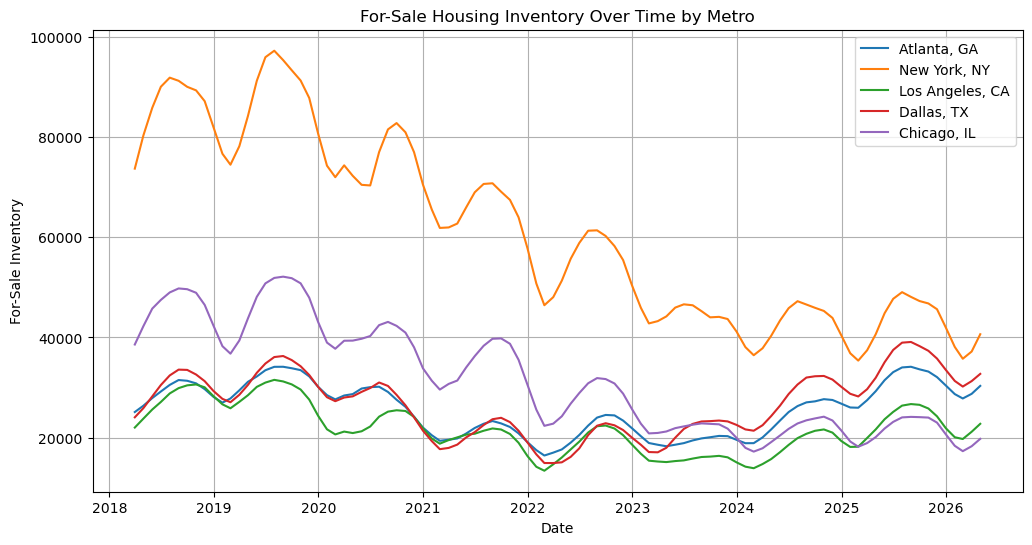

In [3]:
selected_metros = [
    "Atlanta, GA",
    "New York, NY",
    "Los Angeles, CA",
    "Dallas, TX",
    "Chicago, IL"
]

line_df = metro_df[metro_df["RegionName"].isin(selected_metros)]

plt.figure(figsize=(12, 6))

for metro in selected_metros:
    temp = line_df[line_df["RegionName"] == metro]
    plt.plot(temp["Date"], temp["Inventory"], label=metro)

plt.title("For-Sale Housing Inventory Over Time by Metro")
plt.xlabel("Date")
plt.ylabel("For-Sale Inventory")
plt.legend()
plt.grid(True)
plt.show()

This line graph displays how the housing availability has changed over time. It indicates that since 2018, availability has went up and down slightly in NY yet decreased significantly.
Other cities noticed a decline in availability yet not such as much as New York, while Dallas and Atlanta bounced back up.

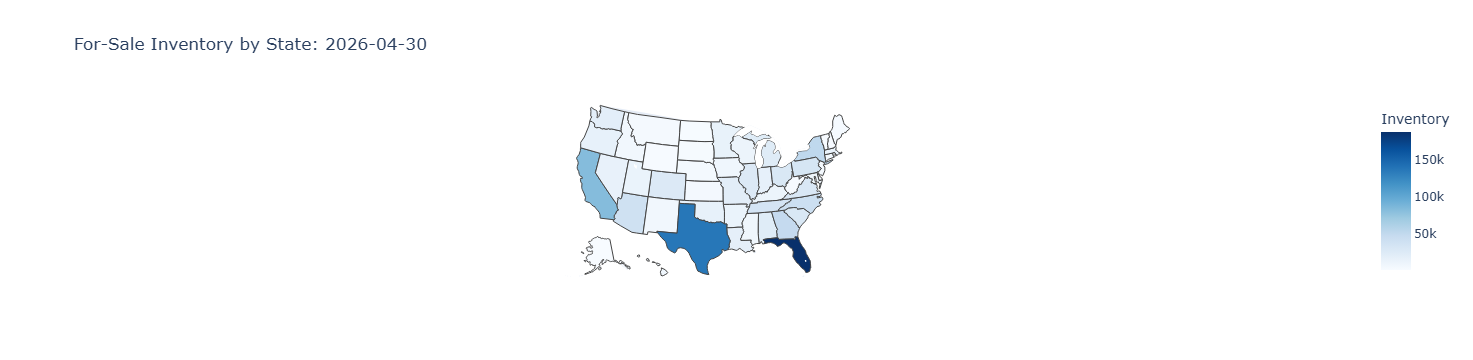

In [4]:
latest_date = metro_df["Date"].max()

state_df = (
    metro_df[metro_df["Date"] == latest_date]
    .groupby("StateName", as_index=False)["Inventory"]
    .sum()
)

fig = px.choropleth(
    state_df,
    locations="StateName",
    locationmode="USA-states",
    color="Inventory",
    scope="usa",
    title=f"For-Sale Inventory by State: {latest_date.date()}",
    color_continuous_scale="Blues"
)

fig.show()

The map shows distribution of for sale inventory across the US in the month of April 2026. Florida, Texas, and California seem to have the most inventory compared to the other states. Places with larger metro areas have more inventory. 

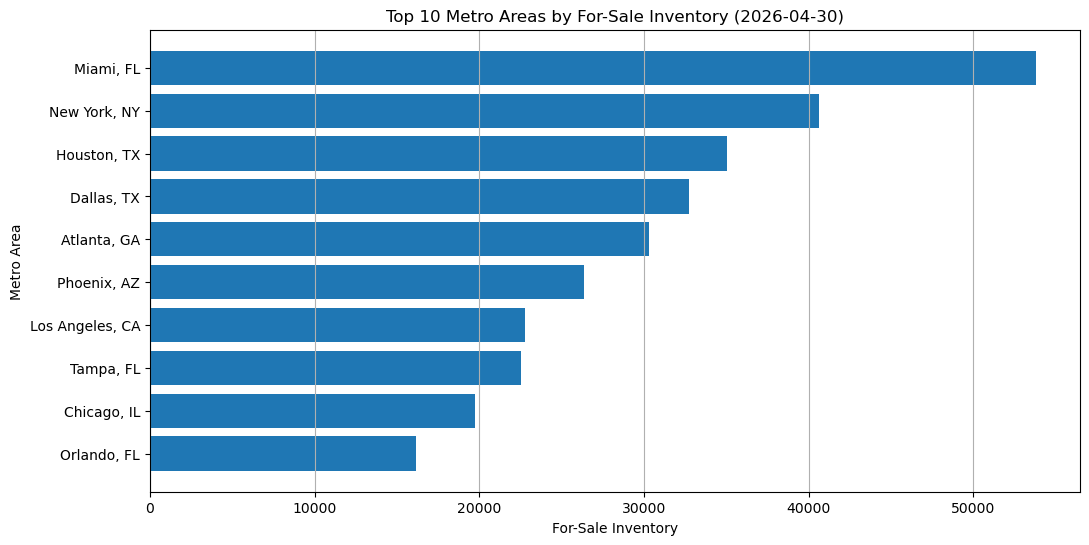

In [7]:
latest_date = metro_df["Date"].max()

latest_inventory = (
    metro_df[metro_df["Date"] == latest_date]
    .sort_values("Inventory", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(latest_inventory["RegionName"], latest_inventory["Inventory"])
plt.title(f"Top 10 Metro Areas by For-Sale Inventory ({latest_date.date()})")
plt.xlabel("For-Sale Inventory")
plt.ylabel("Metro Area")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

This bar chart indicates the metro areas which had the highest number of active listings for sale in April 2026. It seems that larger metro areas have higher inventory. This shows that
housing availability varies geographically.